## Imports

In [1]:
from astroquery.sdss import SDSS
from astropy.io import fits

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

import datetime
import os
import re
import joblib

In [2]:
data_dir = "../astro_sandbox/data/starspectra"
data_output_dir = "../astro_sandbox/data_output/starspectra"

## Load Data (Local)

Once the data is handy - we can just load the metadata (pandas df)   
and the fits file containing spectrum information in the fits_data object

In [3]:
df = pd.read_csv(f"{data_dir}/BalancedStarSpectra500_Winnie.csv")
df['major_type'] = df['subclass'].str.extract(r'^([OBAFGKM])')
# df.info()

In [4]:
df.shape

(3192, 40)

In [5]:
# df.head(1)

Spectrum could be different length - we try to have them in the same wavelength grid  
https://www.sdss4.org/dr17/spectro/spectro_basics/  
Based on the wavelngth coverage mentioned on the SDSS -  
Wave Min and Wave Max is supposed to be 3800-9200 (Angstroms) for SDSS  
 and its 3650-10400 for BOSS - we set our constants to the latter as they cover wider range

Also native resolution of SDSS seems to be 2.53-3.60 Angstroms  
1500 Angstroms / 3800 = 2.53 Angstroms  
9000 Angstroms / 2500 = 3.60 Angstroms  

the bins are selected to reduce the resolution a bit (but we can have more bins upto even 5000 as we'll just reach 1.35 Angtroms)


In [6]:
SPECTRAL_CLASSES = {'O', 'B', 'A', 'F', 'G', 'K', 'M'}
WAVE_MIN, WAVE_MAX, N_BINS = 3800, 9200, 3600 # Number of bins = (9200-3800) / 1.5 (desired resolution) = 3600
# WAVE_MIN, WAVE_MAX, N_BINS = 3650, 10400, 2000
COMMON_WAVE = np.linspace(WAVE_MIN, WAVE_MAX, N_BINS)

def load_local_spectrum(fits_path):
    try:
        with fits.open(fits_path) as hdul:
            data = hdul[1].data
            wavelength = 10**data['loglam'] # Converting wavelengths to linear scale
            flux = data['flux'] 

            # valid_wave = wavelength[flux > 0]
            # wv_min = max(WAVE_MIN, valid_wave.min())
            # wv_max = min(WAVE_MAX, valid_wave.max())
            # COMMON_WAVE = np.linspace(wv_min, wv_max, N_BINS)

            mask = flux > 0
            if not np.any(mask):
                return None

            interp_flux = interp1d(wavelength[mask], flux[mask], bounds_error=False, fill_value=0.0) #Estimating flux
            flux_resampled = interp_flux(COMMON_WAVE) #resample flux
            # median = np.median(flux_resampled[np.nonzero(flux_resampled)])
            median = np.median(flux_resampled[flux_resampled > 0])

            return flux_resampled / median if median else None #median normalization
    except Exception as e:
        print(f"Error loading {fits_path}: {e}")
        return None

In [7]:
fits_data = {}
for _, row in df.iterrows():
    plate, mjd, fiberID, subclass, majorclass = row['plate'], row['mjd'], row['fiberID'], row['subclass'], row['major_type']
    fits_path = f"{data_dir}/raw_fits500/spec-{plate}-{mjd}-{fiberID}.fits"
    spectrum = load_local_spectrum(fits_path)
    if spectrum is not None:
        fits_data[(plate, mjd, fiberID)] = (spectrum, subclass, majorclass)
        # plot_spectrum(COMMON_WAVE, spectrum, f"{majorclass}-{subclass}", plate, mjd, fiberID)

Error loading ../astro_sandbox/data/starspectra/raw_fits500/spec-3853-55268-212.fits: [Errno 2] No such file or directory: '../astro_sandbox/data/starspectra/raw_fits500/spec-3853-55268-212.fits'


In [8]:
len(fits_data.keys())

3191

## Standard Normalization Techniques

Here we explore well known normalization techniques

### Min Max Scaling

Linearly rescales values using minimum and maximum values to the [0, 1] range.  
(flux - min(flux)) / (max(flux) - min(flux) + 1e-8)

In [9]:
def normalize_min_max(spectra):
    spectra_min = spectra.min(axis=1, keepdims=True)
    spectra_max = spectra.max(axis=1, keepdims=True)
    return (spectra - spectra_min) / (spectra_max - spectra_min + 1e-8)

### Z Scaling

Centers data at zero mean, unit variance   
(flux - mean(flux)) / (std(flux) + 1e-8)



In [10]:
def normalize_z_score(spectra):
    mean = spectra.mean(axis=1, keepdims=True)
    std = spectra.std(axis=1, keepdims=True)
    return (spectra - mean) / (std + 1e-8)

### AUC norm

Normalizes based on total energy (integrated flux)  
flux / (∫ flux dλ + 1e-8)

In [21]:

def normalize_auc(spectra):
    # area = np.trapz(spectra, COMMON_WAVE, axis=1).reshape(-1, 1)
    # numpy doesnt have np.trapz
    area = np.sum(spectra, axis=1, keepdims=True)
    return spectra / (area + 1e-8)


### Max Norm

In [12]:
def normalize_max(spectrum):
    return spectrum / (np.max(spectrum) + 1e-8)



### L2 Norm

In [13]:
def normalize_l2(spectrum):
    norm = np.linalg.norm(spectrum)
    return spectrum / (norm + 1e-8)


### IQR norm

In [14]:
def normalize_robust(spectrum):
    median = np.median(spectrum)
    iqr = np.percentile(spectrum, 75) - np.percentile(spectrum, 25)
    return (spectrum - median) / (iqr + 1e-8)


### Log Norm

In [15]:
def normalize_log(spectra):
    return np.log1p(spectra)  # log(1 + x)



### Quantile Norm

In [16]:
def normalize_quantile(spectra):
    sorted_X = np.sort(spectra, axis=1)
    ranks = np.argsort(np.argsort(spectra, axis=1), axis=1)
    avg_dist = np.mean(sorted_X, axis=0)
    return avg_dist[ranks]

### Evaluate

#### Spectra Normalization

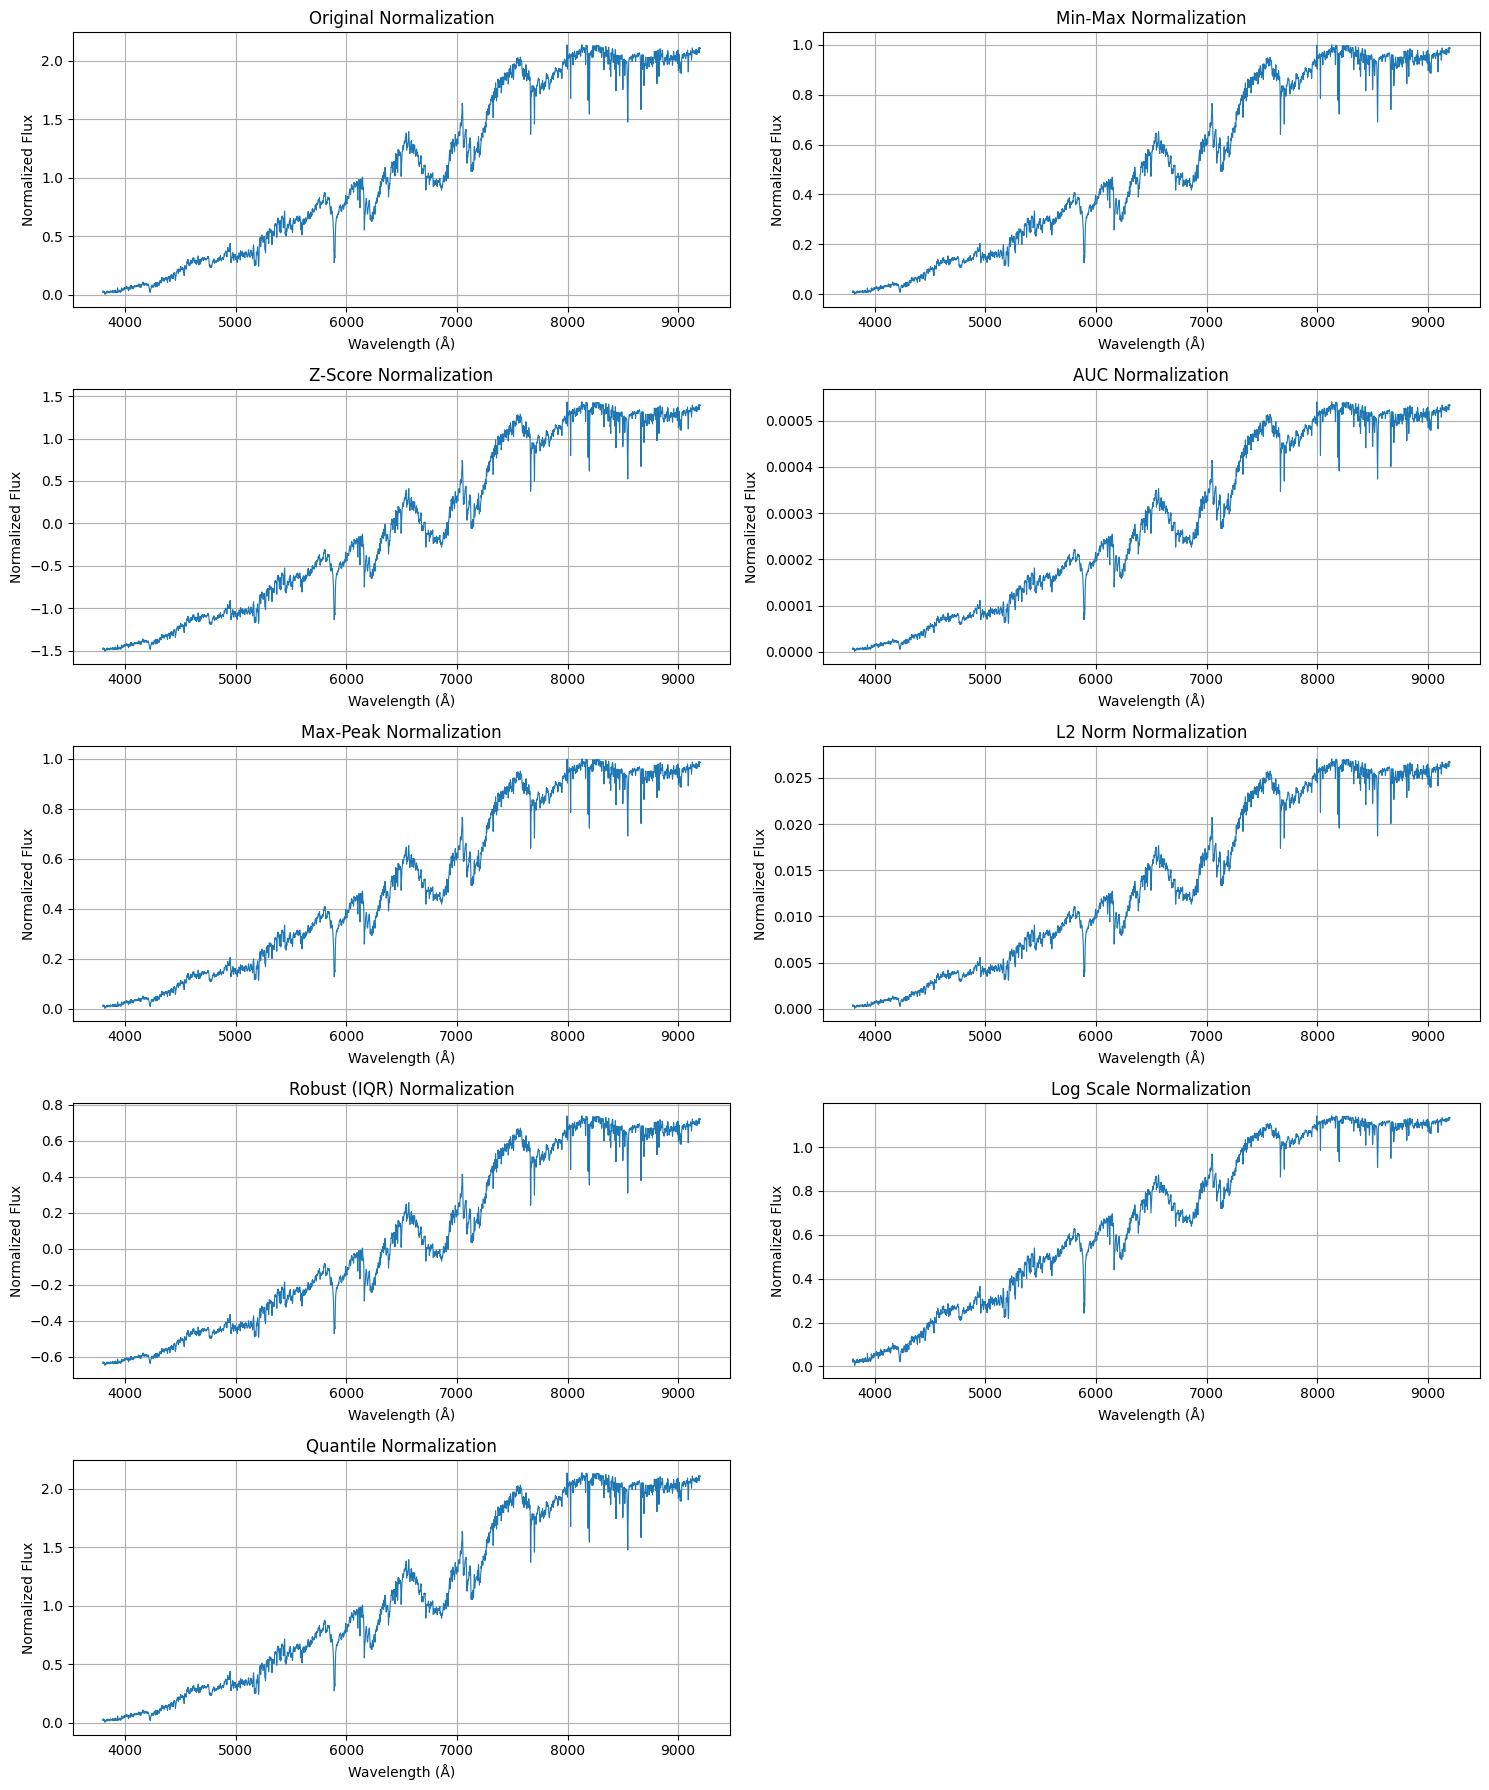

In [22]:
#11060, 58523, 493#4050, 55599, 14#3794, 55241, 954#1259, 52931, 638
spectrum, subclass, majorclass = fits_data[(11060, 58523, 493)]
X = np.array([spectrum])

methods = {
    "Original": X[0],
    "Min-Max": normalize_min_max(X)[0],
    "Z-Score": normalize_z_score(X)[0],
    "AUC": normalize_auc(X)[0],
    "Max-Peak": normalize_max(X)[0],
    "L2 Norm": normalize_l2(X)[0],
    "Robust (IQR)": normalize_robust(X)[0],
    "Log Scale": normalize_log(X)[0],
    "Quantile": normalize_quantile(X)[0]
}

plt.figure(figsize=(15, 18))
for i, (label, norm_flux) in enumerate(methods.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    plt.plot(COMMON_WAVE, norm_flux, lw=0.8)
    plt.title(f"{label} Normalization")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    # plt.savefig(f"sample_norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Feature Normalization

In [23]:
X_all = np.array([s for (s, _, _) in fits_data.values()]) 

# X_norms = {
#     "Original": X_all,
#     "Min-Max": normalize_min_max(X_all),
#     "Z-Score": normalize_z_score(X_all),
#     "AUC": normalize_auc(X_all),
#     "Max-Peak": normalize_max(X_all),
#     "L2 Norm": normalize_l2(X_all),
#     "Robust (IQR)": normalize_robust(X_all),
#     "Log Scale": normalize_log(X_all),
#     "Quantile": normalize_quantile(X_all)
# }

In [27]:
def normalize_min_max_global(X):
    min_vals = X.min(axis=0, keepdims=True)
    max_vals = X.max(axis=0, keepdims=True)
    return (X - min_vals) / (max_vals - min_vals + 1e-8)

def normalize_z_score_global(X):
    mean_vals = X.mean(axis=0, keepdims=True)
    std_vals = X.std(axis=0, keepdims=True)
    return (X - mean_vals) / (std_vals + 1e-8)

def normalize_auc_global(X):
    # aucs = np.trapz(X, COMMON_WAVE, axis=1, keepdims=True)
    # aucs = np.trapz(X, COMMON_WAVE, axis=1).reshape(-1, 1)
    aucs = np.sum(X, axis=1, keepdims=True)
    return X / (aucs + 1e-8)

def normalize_max_global(X):
    max_vals = X.max(axis=1, keepdims=True)
    return X / (max_vals + 1e-8)

def normalize_l2_global(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + 1e-8)

def normalize_robust_global(X):
    median_vals = np.median(X, axis=0, keepdims=True)
    iqr_vals = np.percentile(X, 75, axis=0, keepdims=True) - np.percentile(X, 25, axis=0, keepdims=True)
    return (X - median_vals) / (iqr_vals + 1e-8)

def normalize_log_global(X):
    return np.log1p(X)  # log(1 + x)

def normalize_quantile_global(X):
    sorted_X = np.sort(X, axis=0)
    ranks = np.argsort(np.argsort(X, axis=0), axis=0)
    avg_dist = np.mean(sorted_X, axis=0)
    return avg_dist[ranks]

# Apply all methods
X_norms = {
    "Original": X_all,
    "Min-Max": normalize_min_max_global(X_all),
    "Z-Score": normalize_z_score_global(X_all),
    "AUC": normalize_auc_global(X_all),
    "Max-Peak": normalize_max_global(X_all),
    "L2 Norm": normalize_l2_global(X_all),
    "Robust (IQR)": normalize_robust_global(X_all),
    "Log Scale": normalize_log_global(X_all),
    "Quantile": normalize_quantile_global(X_all)
}

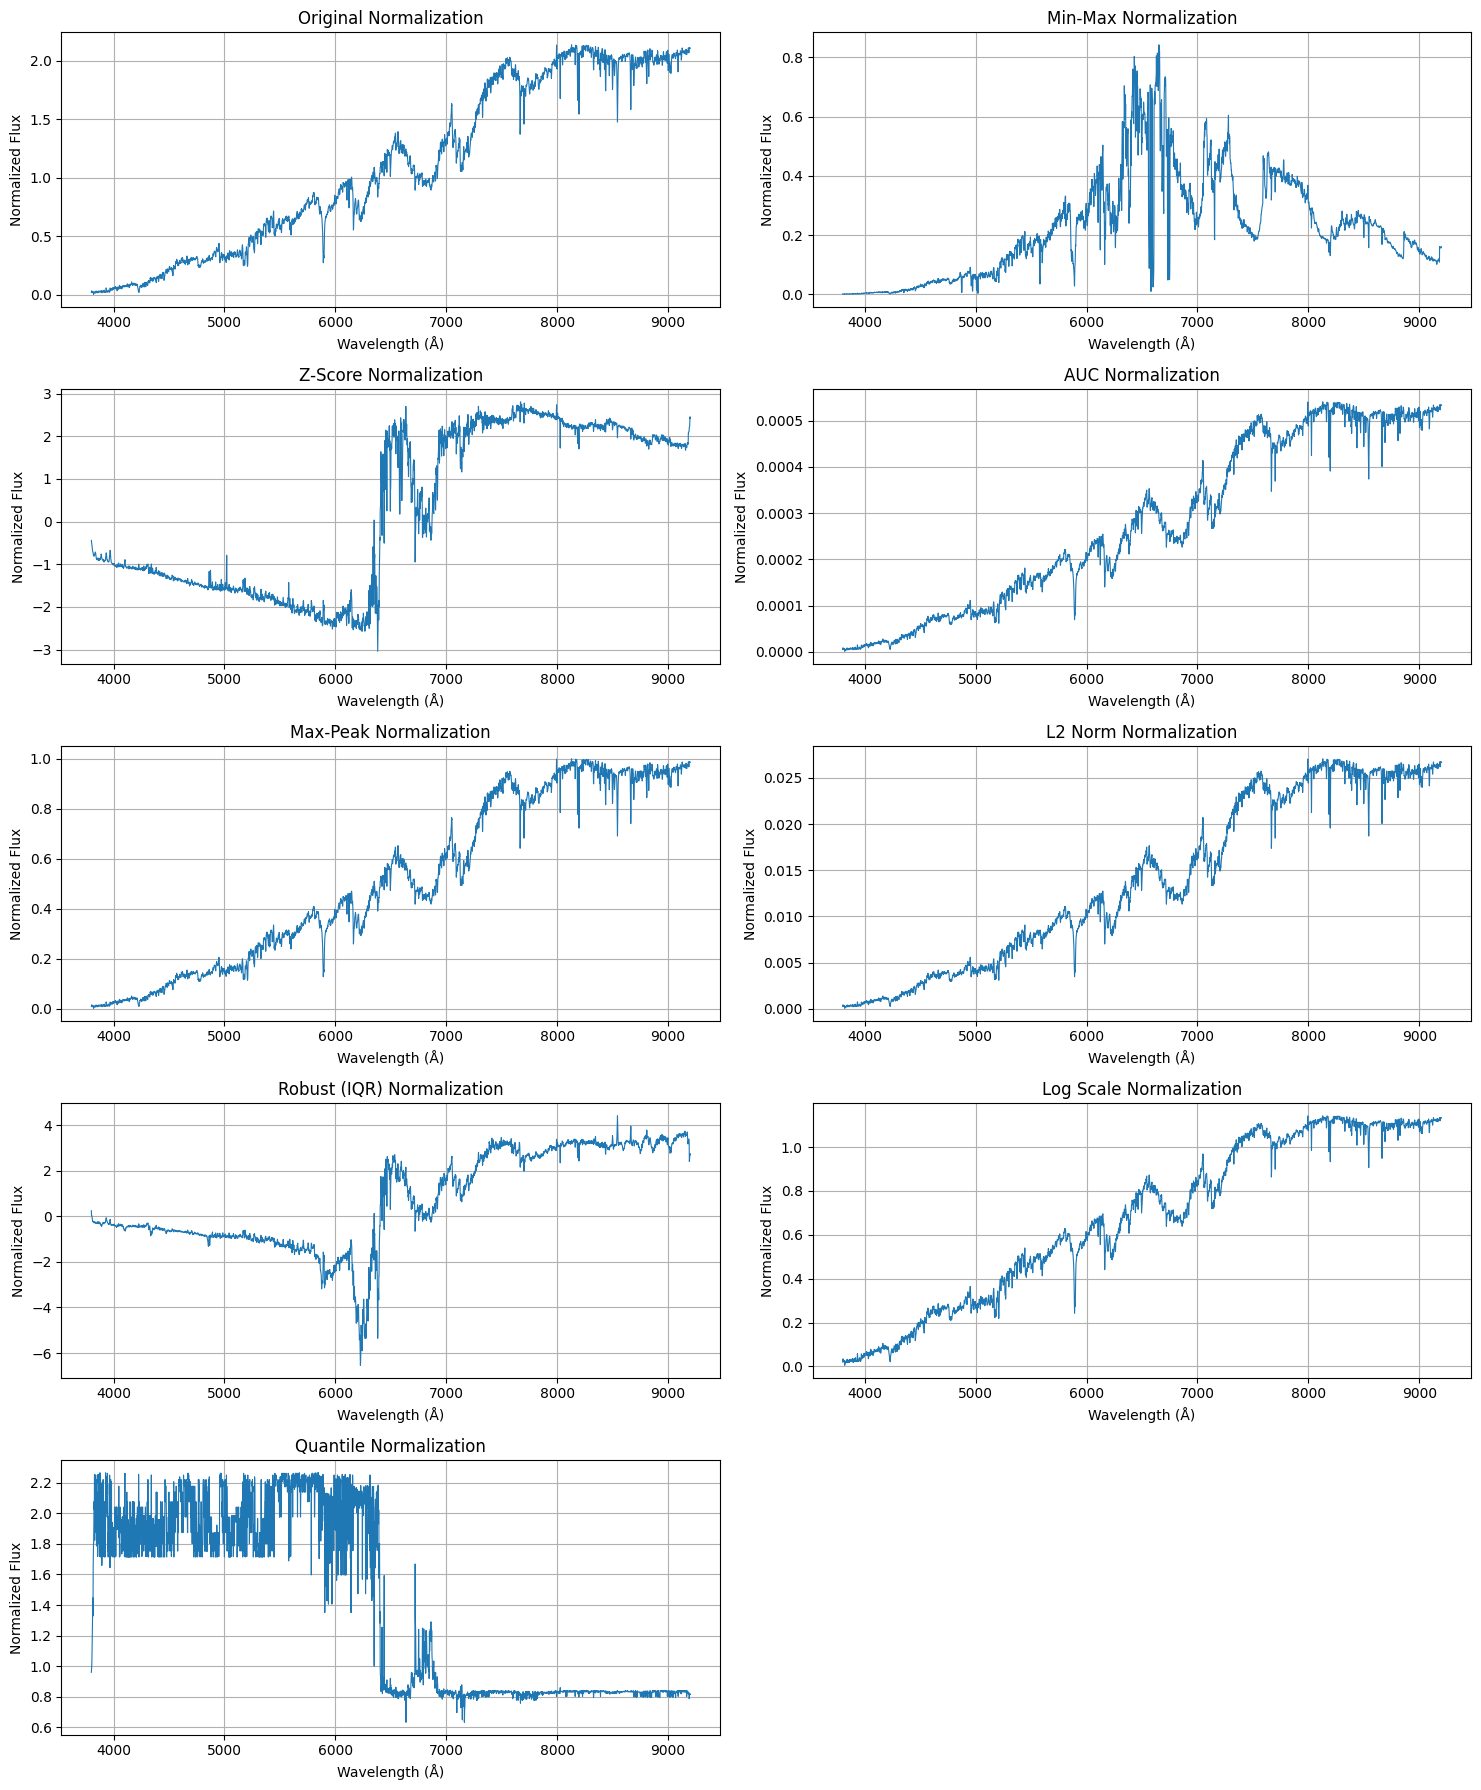

In [28]:
target_key = (11060, 58523, 493)
target_index = list(fits_data.keys()).index(target_key)

plt.figure(figsize=(15, 18))
for i, (label, Xn) in enumerate(X_norms.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    # plt.plot(COMMON_WAVE, norm_flux, lw=0.8)
    plt.plot(COMMON_WAVE, Xn[target_index], lw=0.8)
    plt.title(f"{label} Normalization")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    # plt.savefig(f"norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


##### Distribution

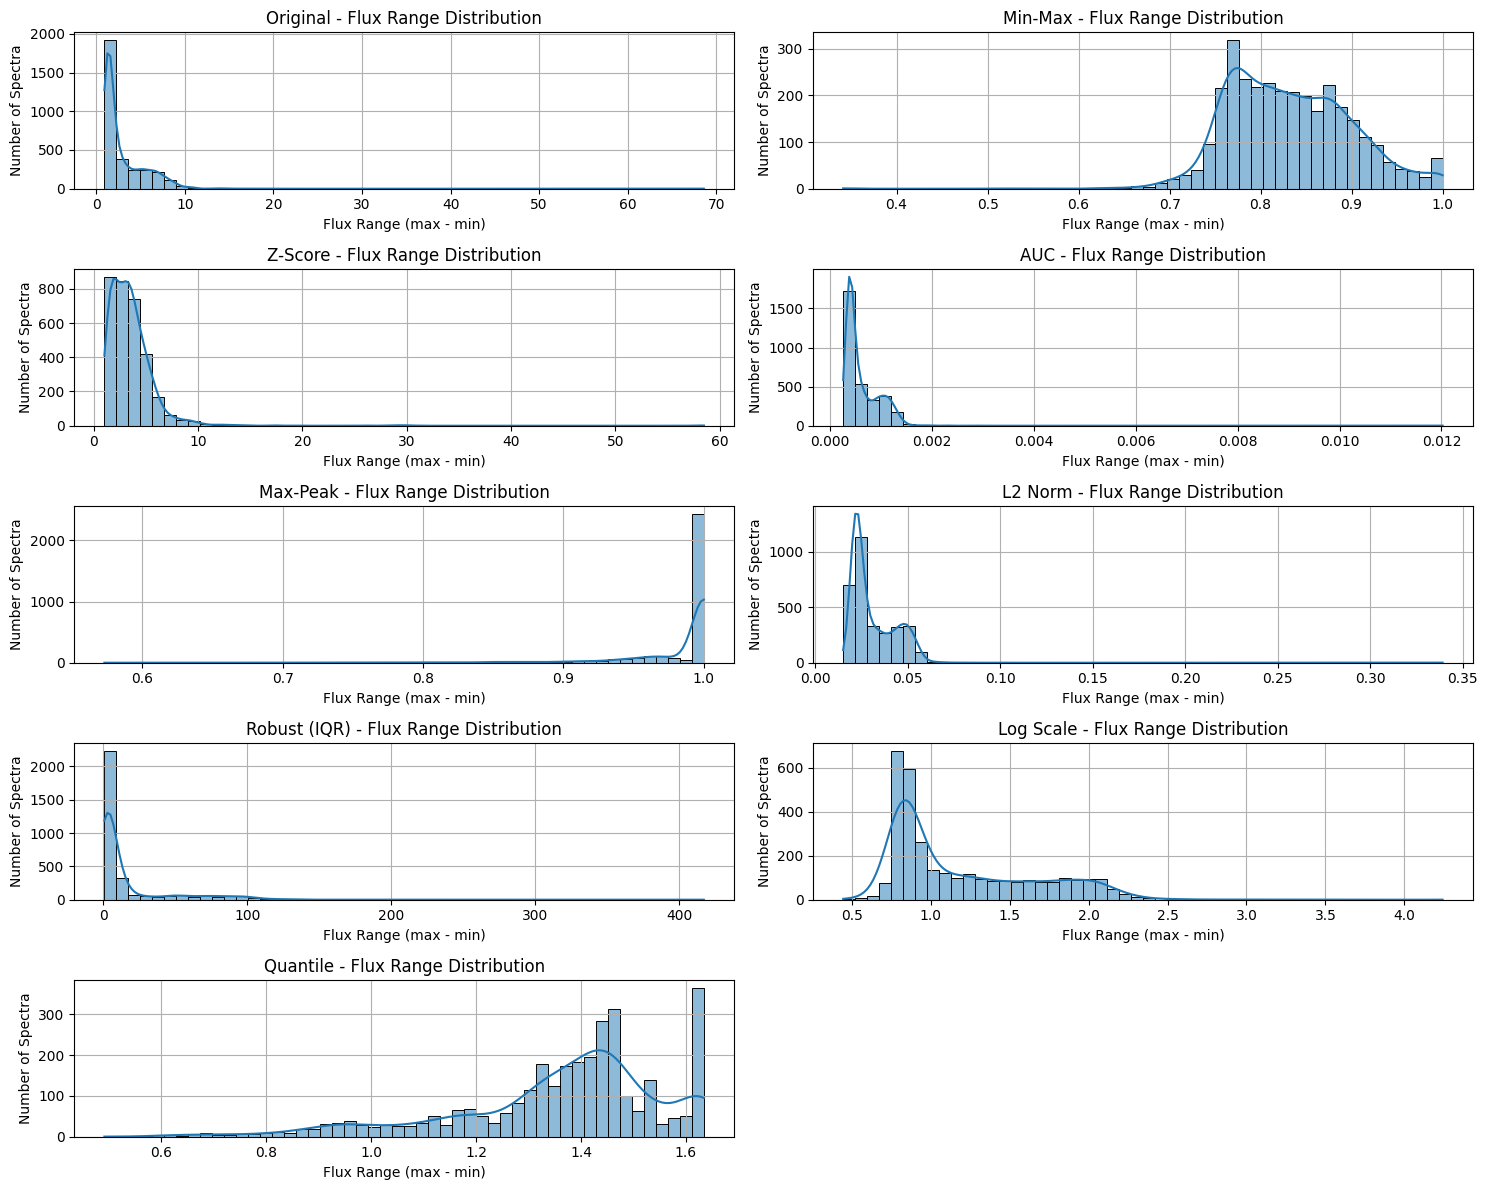

In [29]:
def compute_flux_stats(spectra):
    return pd.DataFrame({
        'min_flux': np.min(spectra, axis=1),
        'max_flux': np.max(spectra, axis=1),
        'mean_flux': np.mean(spectra, axis=1),
        'median_flux': np.median(spectra, axis=1),
        'range_flux': np.ptp(spectra, axis=1),  # max - min
    })

# Compute stats for each normalization method
stats_by_method = {label: compute_flux_stats(Xn) for label, Xn in X_norms.items()}

# Plot distribution of flux ranges for each
plt.figure(figsize=(15, 12))
for i, (label, stats_df) in enumerate(stats_by_method.items(), 1):
    plt.subplot(5, 2, i)
    # plt.figure(figsize=(12, 4))
    sns.histplot(stats_df['range_flux'], bins=50, kde=True)
    plt.title(f"{label} - Flux Range Distribution")
    plt.xlabel("Flux Range (max - min)")
    plt.ylabel("Number of Spectra")
    # plt.savefig(f"dist_norm_{label}")
    # plt.tight_layout()
    # plt.close()
    plt.grid(True)

plt.tight_layout()
plt.show()


## Normalize

In [38]:
X, y, idx = [], [], []

for (plate, mjd, fiberID), (spectrum, subclass, majorclass) in fits_data.items():
    X.append(spectrum)
    y.append(majorclass)
    idx.append((plate, mjd, fiberID))

X = np.array(X)
y = np.array(y)

In [39]:
X_norm = []

for flux in X:
    flux_auto, cont_auto, method_used = auto_continuum_normalize(COMMON_WAVE, flux, verbose=False)
    X_norm.append(flux_auto)

X_norm = np.array(X_norm)



#### Inspect

In [40]:
def compute_flux_stats(spectra):
    stats = {
        'min_flux': np.min(spectra, axis=1),
        'max_flux': np.max(spectra, axis=1),
        'mean_flux': np.mean(spectra, axis=1),
        'median_flux': np.median(spectra, axis=1),
        'range_flux': np.ptp(spectra, axis=1),  # max - min
    }
    return pd.DataFrame(stats)

flux_stats_df = compute_flux_stats(X)
flux_stats_df_norm = compute_flux_stats(X_norm)

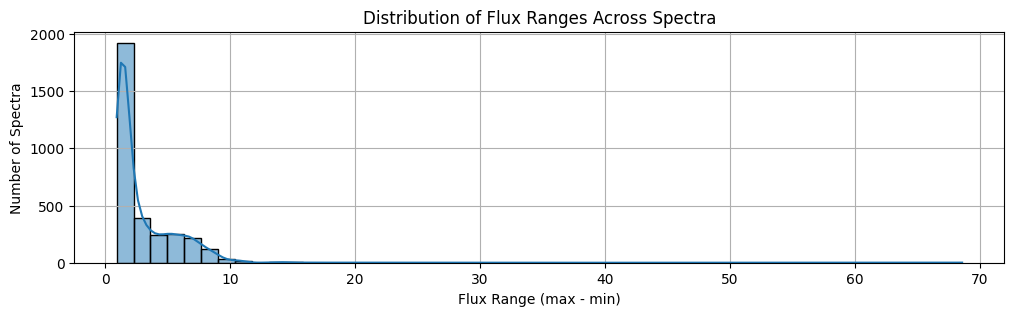

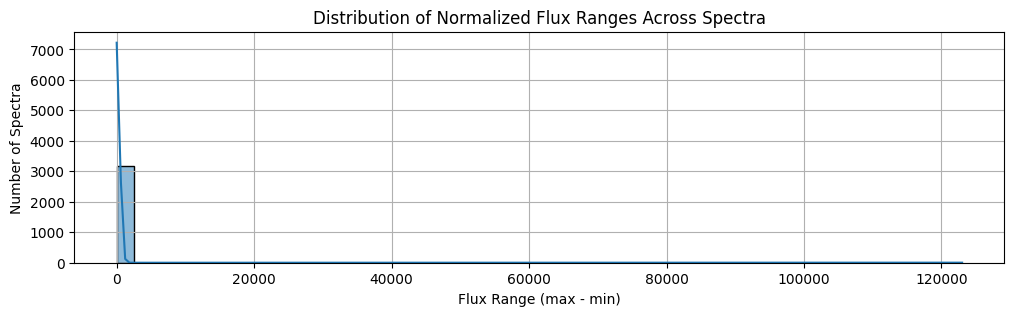

In [41]:
plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df['range_flux'], bins=50, kde=True)
plt.title("Distribution of Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df_norm['range_flux'], bins=50, kde=True)
plt.title("Distribution of Normalized Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

In [42]:
def plot_all_continuum_distributions(X_raw, wave, methods=None):
    if methods is None:
        methods = {
            "Savgol": lambda wave, flux: continuum_savgol(flux)[0],
            "Spline": lambda wave, flux: continuum_spline(wave, flux)[0],
            "Polynomial": lambda wave, flux: continuum_polynomial(wave, flux)[0],
            "Spline_WSavgol": lambda wave, flux: continuum_spline_wsavgol(wave, flux)[0],
            "Poly_Weighted": lambda wave, flux: continuum_polynomial_weighted(wave, flux)[0],
            "Auto": lambda wave, flux: auto_continuum_normalize(wave, flux, verbose=False)[0]
        }

    norm_data = {label: [] for label in methods}

    # Normalize each spectrum using all methods
    for flux in X_raw:
        for label, method_func in methods.items():
            try:
                norm_flux = method_func(wave, flux)
                norm_data[label].append(norm_flux)
            except Exception as e:
                print(f"{label} failed on a spectrum: {e}")
                continue

    # Compute flux range statistics
    plt.figure(figsize=(15, len(norm_data) * 2.5))
    for i, (label, spectra) in enumerate(norm_data.items(), 1):
        stats_df = compute_flux_stats(np.array(spectra))
        plt.subplot(len(norm_data), 1, i)
        sns.histplot(stats_df['range_flux'], bins=50, kde=True)
        plt.title(f"{label} - Flux Range Distribution")
        plt.xlabel("Flux Range (max - min)")
        plt.ylabel("Count")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


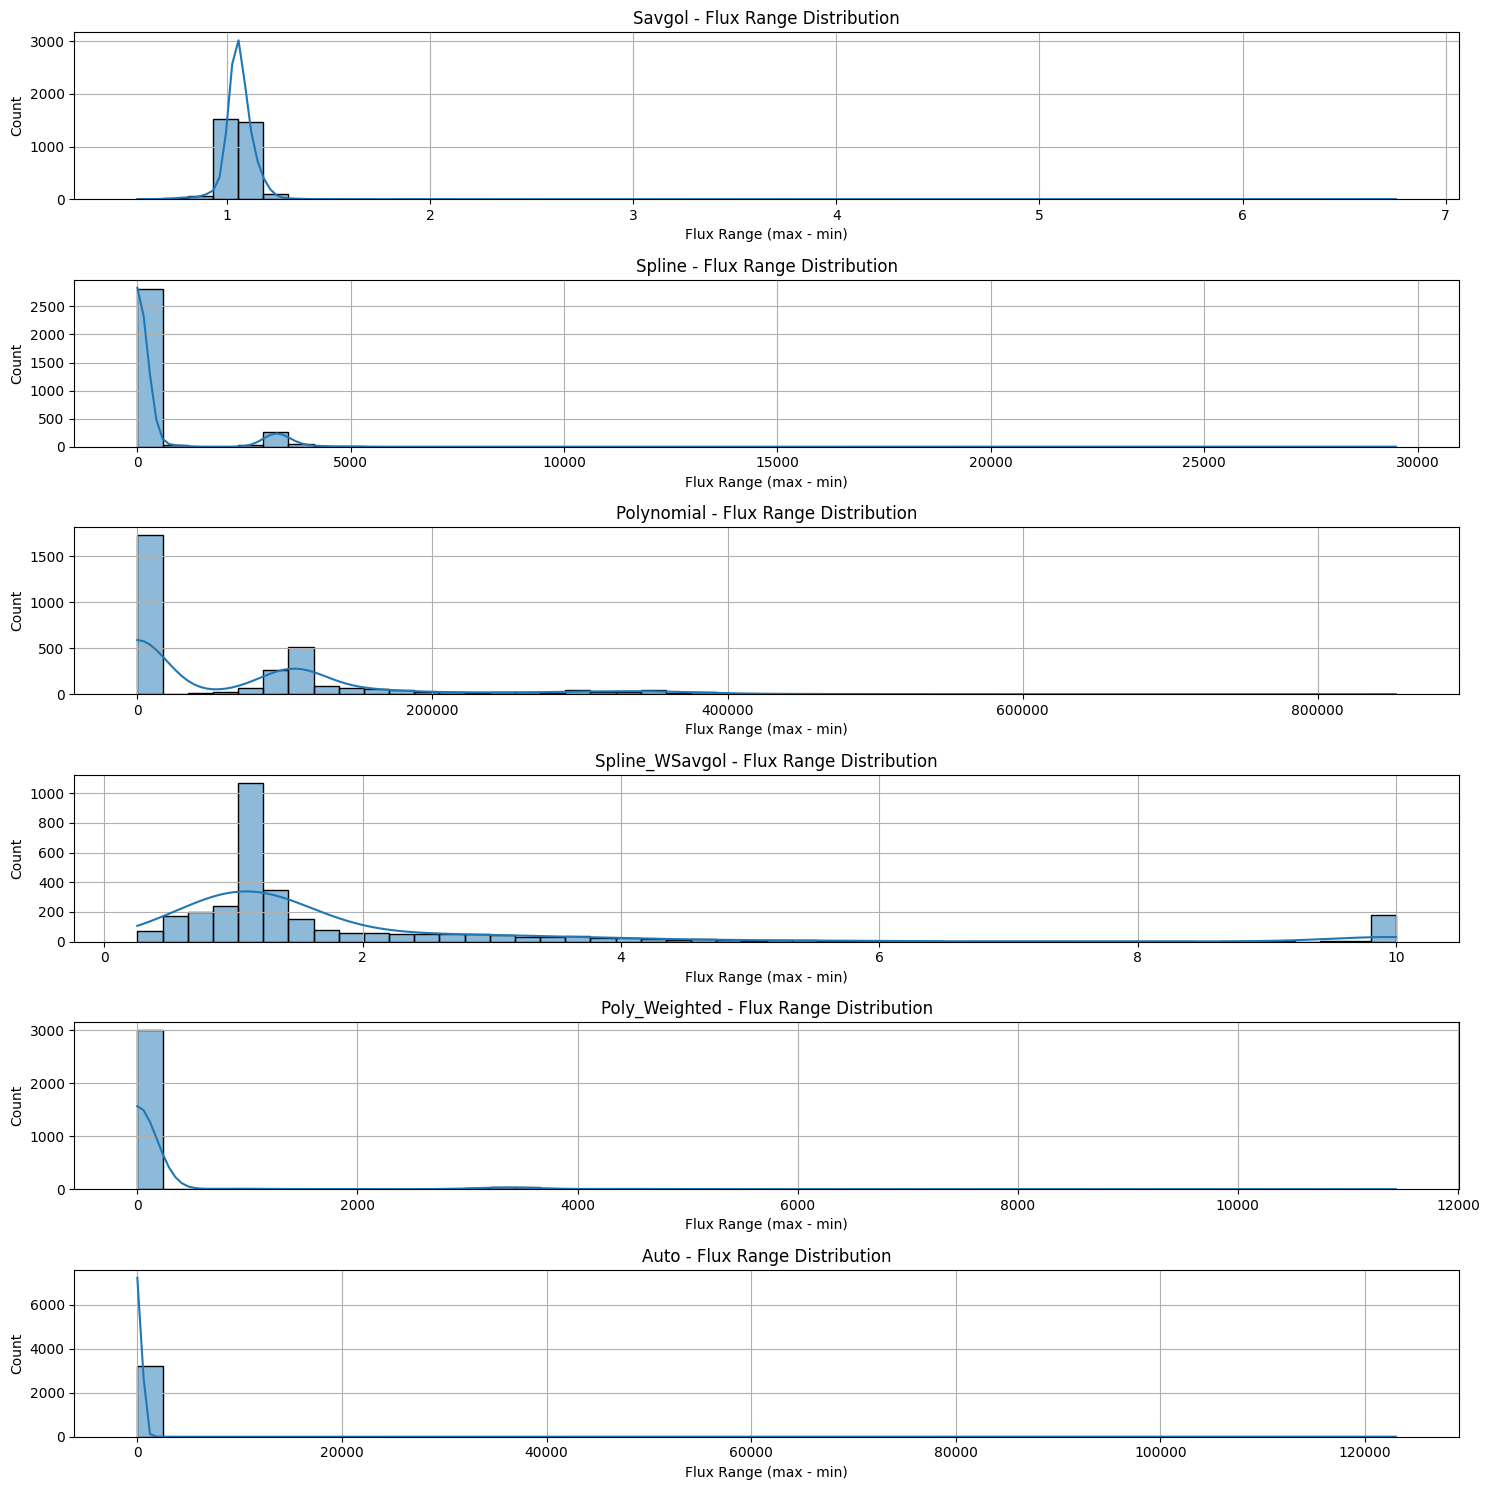

In [43]:
plot_all_continuum_distributions(X, COMMON_WAVE)

#### Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.signal import savgol_filter, medfilt
from scipy.interpolate import UnivariateSpline

def create_method_animation(wave, flux, method='spline_wsavgol', save_path='animation.gif'):
    """
    Creates a slowed-down animation for any of the four continuum methods.
    """
    fig, (ax_proc, ax_res) = plt.subplots(2, 1, figsize=(12, 10))
    plt.subplots_adjust(hspace=0.3)
    
    # Background spectrum
    ax_proc.plot(wave, flux, color='gray', alpha=0.3, label='Raw Spectrum')
    ax_res.plot(wave, flux, color='gray', alpha=0.3, label='Raw Spectrum')
    
    # Animated elements
    line_proc, = ax_proc.plot([], [], color='red', lw=2, label='Current Window/Process')
    scatter_pts = ax_proc.scatter([], [], color='green', s=15, label='Anchors/High-Weights')
    line_res, = ax_res.plot([], [], color='blue', lw=2.5, label='Fitted Continuum')

    # Setup per method
    if method == 'savgol':
        window = 151
        step = 40
        frames = range(0, len(wave) - window, step)
        ax_proc.set_title("Savgol: Local Sliding Window (Degree 3 Poly)")
        
        def update(i):
            start, end = i, i + window
            z = np.polyfit(wave[start:end], flux[start:end], 3)
            p = np.poly1d(z)
            line_proc.set_data(wave[start:end], p(wave[start:end]))
            # Update bottom with partial savgol
            current_cont = savgol_filter(flux[:end], window, 3)
            line_res.set_data(wave[:len(current_cont)], current_cont)
            return line_proc, line_res

    elif method in ['spline_wsavgol', 'polynomial']:
        n_bins = 20
        bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
        frames = range(n_bins)
        ax_proc.set_title(f"{method}: Step-by-Step Binning & Anchor Selection")
        
        all_x, all_y = [], []
        
        def update(i):
            in_bin = (wave >= bins[i]) & (wave < bins[i+1])
            if np.any(in_bin):
                idx = np.where(in_bin)[0]
                # Using your logic: top 15 points per bin
                top_idx = idx[np.argsort(flux[idx])[-15:]]
                all_x.extend(wave[top_idx])
                all_y.extend(flux[top_idx])
            
            scatter_pts.set_offsets(np.column_stack((all_x, all_y)))
            
            # Show fit only after we have enough data (midway)
            if i > 5:
                # Sort for interpolation stability
                s_idx = np.argsort(all_x)
                if method == 'spline_wsavgol':
                    s = 1e-4 * len(wave) * np.median(flux)**2
                    spline = UnivariateSpline(np.array(all_x)[s_idx], np.array(all_y)[s_idx], s=s)
                    line_res.set_data(wave, spline(wave))
                else:
                    z = np.polyfit(all_x, all_y, 4)
                    line_res.set_data(wave, np.poly1d(z)(wave))
            return scatter_pts, line_res

    elif method == 'polynomial_weighted':
        frames = range(10)
        ax_proc.set_title("Weighted Polynomial: Evolution of Point Weights")
        
        # Calculate weights once using your script logic
        smoothed = medfilt(flux, kernel_size=15)
        residual = flux - smoothed
        mad = np.median(np.abs(residual - np.median(residual)))
        weights = np.exp(-((residual / (1.4826 * mad)) ** 2))

        def update(i):
            # Reveal points based on weight threshold (gradually adding lower weight points)
            threshold = 1.0 - (i+1)/10.0
            mask = weights >= threshold
            scatter_pts.set_offsets(np.column_stack((wave[mask], flux[mask])))
            
            # Fit final poly based on weights
            z = np.polyfit(wave, flux, 4, w=weights)
            line_res.set_data(wave, np.poly1d(z)(wave))
            return scatter_pts, line_res

    # KEY: interval=500 slows the animation to 0.5 seconds per frame
    ani = FuncAnimation(fig, update, frames=frames, interval=500, blit=True)
    ani.save(save_path, writer=PillowWriter(fps=2))
    plt.close()
    print(f"Animation saved to {save_path}")

# Example usage for all methods


In [87]:
# for m in ['savgol', 'spline_wsavgol', 'polynomial', 'polynomial_weighted', 'spline']:
#     create_method_animation(COMMON_WAVE, spectrum, method=m, save_path=f'{m}_slow.gif')

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.signal import savgol_filter, medfilt
from scipy.interpolate import UnivariateSpline

def create_method_animation(wave, flux, method='spline_wsavgol', save_path='animation.gif'):
    fig, (ax_proc, ax_res) = plt.subplots(2, 1, figsize=(12, 10))
    plt.subplots_adjust(hspace=0.3)
    
    ax_proc.plot(wave, flux, color='gray', alpha=0.3, label='Raw Spectrum')
    ax_res.plot(wave, flux, color='gray', alpha=0.3, label='Raw Spectrum')
    
    line_proc, = ax_proc.plot([], [], color='red', lw=2, label='Process/Fit')
    scatter_pts = ax_proc.scatter([], [], color='green', s=15, label='Selected Points')
    line_res, = ax_res.plot([], [], color='blue', lw=2.5, label='Continuum Fit')

    if method == 'savgol':
        window = 151
        step = 40
        frames = range(0, len(wave) - window, step)
        ax_proc.set_title("Savgol Filter: Sliding Window (Degree 3)")

        def update(i):
            start, end = i, i + window
            z = np.polyfit(wave[start:end], flux[start:end], 3)
            p = np.poly1d(z)
            line_proc.set_data(wave[start:end], p(wave[start:end]))
            current_cont = savgol_filter(flux[:end], window_length=151, polyorder=3)
            line_res.set_data(wave[:end], current_cont)
            return line_proc, line_res

    elif method == 'spline':
        n_bins = 20
        bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
        frames = range(n_bins)
        ax_proc.set_title("Spline: High-Percentile Anchor Points")

        all_x, all_y = [], []

        def update(i):
            in_bin = (wave >= bins[i]) & (wave < bins[i + 1])
            if np.any(in_bin):
                idx = np.where(in_bin)[0]
                threshold = np.percentile(flux[idx], 95)
                selected_idx = idx[flux[idx] >= threshold]
                all_x.extend(wave[selected_idx])
                all_y.extend(flux[selected_idx])

            scatter_pts.set_offsets(np.column_stack((all_x, all_y)))

            if len(all_x) > 10:
                s = 1e-4 * (wave.max() - wave.min()) * len(wave)
                sorted_idx = np.argsort(all_x)
                spline = UnivariateSpline(np.array(all_x)[sorted_idx], np.array(all_y)[sorted_idx], s=s)
                line_res.set_data(wave, spline(wave))
            return scatter_pts, line_res

    elif method == 'spline_wsavgol':
        n_bins = 20
        bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
        frames = range(n_bins)
        ax_proc.set_title("Spline + Savitzky-Golay: Smoothed & Sigma-Clipped")

        # Initial smoothing
        smoothed = savgol_filter(medfilt(flux, 15), 151, 3)

        # Sigma clipping (4 iterations)
        mask_clip = np.ones_like(flux, dtype=bool)
        for _ in range(4):
            residual = flux[mask_clip] - smoothed[mask_clip]
            mad = np.median(np.abs(residual - np.median(residual)))
            std = 1.4826 * mad if mad > 0 else 1e-5
            mask_clip[mask_clip] = np.abs(residual) < 2.5 * std

        all_x, all_y = [], []

        def update(i):
            in_bin = (wave >= bins[i]) & (wave < bins[i + 1]) & mask_clip
            idx = np.where(in_bin)[0]
            if len(idx) > 0:
                top_idx = idx[np.argsort(flux[idx])[-min(15, len(idx)):]]
                all_x.extend(wave[top_idx])
                all_y.extend(flux[top_idx])

            scatter_pts.set_offsets(np.column_stack((all_x, all_y)))

            if len(all_x) > 10:
                wave_scaled = (wave - wave.mean()) / wave.std()
                x_scaled = (np.array(all_x) - wave.mean()) / wave.std()
                y_sorted = np.array(all_y)[np.argsort(x_scaled)]
                x_sorted = np.sort(x_scaled)
                s = 1e-4 * len(wave) * np.median(flux)**2
                spline = UnivariateSpline(x_sorted, y_sorted, s=s)
                line_res.set_data(wave, spline(wave_scaled))
            return scatter_pts, line_res

    elif method == 'polynomial':
        n_bins = 20
        bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
        frames = range(n_bins)
        ax_proc.set_title("Polynomial Fit: Top Points per Bin")

        all_x, all_y = [], []

        def update(i):
            in_bin = (wave >= bins[i]) & (wave < bins[i + 1])
            idx = np.where(in_bin)[0]
            if len(idx) > 0:
                top_idx = idx[np.argsort(flux[idx])[-min(15, len(idx)):]]
                all_x.extend(wave[top_idx])
                all_y.extend(flux[top_idx])

            scatter_pts.set_offsets(np.column_stack((all_x, all_y)))

            if len(all_x) > 10:
                z = np.polyfit(all_x, all_y, 4)
                line_res.set_data(wave, np.poly1d(z)(wave))
            return scatter_pts, line_res

    elif method == 'polynomial_weighted':
        frames = range(10)
        ax_proc.set_title("Weighted Polynomial: Residual-Based Weights")

        smoothed = medfilt(flux, kernel_size=15)
        residual = flux - smoothed
        mad = np.median(np.abs(residual - np.median(residual)))
        mad = mad if mad > 1e-5 else 1e-3
        weights = np.exp(-((residual / (1.4826 * mad)) ** 2))

        def update(i):
            threshold = 1.0 - (i + 1) / 10.0
            mask = weights >= threshold
            scatter_pts.set_offsets(np.column_stack((wave[mask], flux[mask])))

            z = np.polyfit(wave, flux, 4, w=weights)
            line_res.set_data(wave, np.poly1d(z)(wave))
            return scatter_pts, line_res

    ani = FuncAnimation(fig, update, frames=frames, interval=500, blit=True)
    ani.save(save_path, writer=PillowWriter(fps=2))
    plt.close()
    print(f"Animation saved to {save_path}")


In [91]:
create_method_animation(COMMON_WAVE, spectrum, method='spline', save_path='spline.gif')
create_method_animation(COMMON_WAVE, spectrum, method='spline_wsavgol', save_path='spline_wsavgol.gif')
create_method_animation(COMMON_WAVE, spectrum, method='polynomial', save_path='polynomial.gif')
create_method_animation(COMMON_WAVE, spectrum, method='polynomial_weighted', save_path='poly_weighted.gif')
create_method_animation(COMMON_WAVE, spectrum, method='savgol', save_path='savgol.gif')


Animation saved to spline.gif
Animation saved to spline_wsavgol.gif
Animation saved to polynomial.gif
Animation saved to poly_weighted.gif
Animation saved to savgol.gif
